# Import

In [1]:
import numpy as np
from scipy.stats import norm
import utils

import matplotlib.pyplot as plt
import plotly.graph_objs as go
import matplotlib.pylab as pylab
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import matplotlib.colors as mcolors

import re

import pickle

from importlib import reload

import tqdm

# AMM Simulation Process

In [2]:
reload(utils)

<module 'utils' from '/Users/sebastien/Desktop/AMM-Optimal-Exit-Time/Code/utils.py'>

In [3]:
# Parameters

S0 = 1_000; Y0 = 1_000; trade_size = 1; fee = 0.0001 * trade_size * S0

params_glob = {'sigma': 100, 'rate': 0, 'T': 1, 'S0': S0} 
params_LP = {'a0': 4. , 'a1': 8., 'a2': 0.04, 'ksi': trade_size, 'X0': Y0 * S0, 'Y0': Y0, 'psi': 10**(-2), 'fees_coeff': fee}
params_LP['c'] = params_LP['X0'] * params_LP['Y0']  # Ensure c is set correctly
#params_grid = {'n_paths': 5_000, 'n_steps': 1440}
params_grid = {'n_paths': 5_000, 'n_steps': 2880}

BM_type = 'arithmetic'  # 'geometric' or 'arithmetic'

S_scale_factor = 0.3  # Scale factor for the range of S0
jump_scale_nbr = 50  # Number of jumps to consider in the range of Y0
h = 10
delta = 0.001

time_factor = 0  # Factor to adjust the time step for value function calculation

# Create solver object in order to apply Longstaff-Schwartz method and Euler
amm_solver_obj = utils.Solver(**{**params_glob, **params_grid, **params_LP})

## Value function

In [4]:
request_val = input('Compute Euler vs Longstaff-Schwartz comparison [y/n] ?')

if request_val == 'y':

    # Solving the AMM problem using Euler method
    print('Solving the AMM problem using Euler method', end='')
    res_euler_risk_neutral = amm_solver_obj.euler_v2(delta=delta, h=h, jump_scale_nbr=jump_scale_nbr, S_scale_factor=S_scale_factor, risk_neutral=True)
    value_function_euler_risk_neutral = res_euler_risk_neutral['V_matrix']

    res_euler_risk_averse = amm_solver_obj.euler_v2(delta=delta, h=h, jump_scale_nbr=jump_scale_nbr, S_scale_factor=S_scale_factor, risk_neutral=False)
    value_function_euler_risk_averse = res_euler_risk_averse['V_matrix']
    print('--> Done', end='\n\n')

    value_function_LS_dict = []

    # # Solving the AMM problem using Longstaff-Schwartz method
    # print('Solving the AMM problem using Longstaff-Schwartz method', end='\n\n')

    # # Create a range of S0 values based on the scale factor
    # S0_matrix = np.arange(params_glob['S0']*(1-S_scale_factor), params_glob['S0']*(1+S_scale_factor) + h, h)
    # Y0_matrix = np.array([1000]) #np.array([970,985,1000,1015,1030])

    # value_function_LS_dict = {'Y0' : Y0_matrix,
    #                           'value_function_LS_risk_neutral' : np.zeros((Y0_matrix.shape[0], S0_matrix.shape[0])),
    #                           'value_function_LS_risk_averse' : np.zeros((Y0_matrix.shape[0], S0_matrix.shape[0])),
    #                           'confidence_intervals' : np.zeros((Y0_matrix.shape[0], S0_matrix.shape[0], 2))}
    # j = 0
    # for Y0_val in Y0_matrix:
        
    #     value_function_LS_risk_neutral = np.zeros_like(S0_matrix)
    #     value_function_LS_risk_averse = np.zeros_like(S0_matrix)
    #     params = {**params_glob, **params_grid, **params_LP}
    #     params['Y0'] = Y0_val
    #     params['X0'] = params_LP['c']/params['Y0']  # Update X0 based on Y0 and S0
    #     print(f'LS for Y0 = {params['Y0']}', end='\n')

    #     # Loop over different values of S0
    #     for i in tqdm.tqdm(range(S0_matrix.shape[0])):

    #         params['S0'] = S0_matrix[i]

    #         # Create the solver object
    #         amm_solver_obj = utils.Solver(**params)

    #         # Generate paths
    #         amm_solver_obj.amm_model(BM_type=BM_type)
    #         full_amm_paths = amm_solver_obj.get_paths()
    #         amm_paths = full_amm_paths['amm_model_0']
    #         amm_paths_S = full_amm_paths['external_mid_price_S']
    #         amm_paths_Y = full_amm_paths['asset_Y']

    #         # Calculate the value function at time
    #         res_LS_risk_neutral = amm_solver_obj.longstaff_schwartz(paths=amm_paths, paths_S=amm_paths_S, paths_Y=amm_paths_Y, deg=3, risk_neutral=True)
    #         res_LS_risk_averse = amm_solver_obj.longstaff_schwartz(paths=amm_paths, paths_S=amm_paths_S, paths_Y=amm_paths_Y, deg=3, risk_neutral=False)

    #         value_function_LS_risk_neutral[i] = res_LS_risk_neutral['V_matrix'][:, -1 if time_factor == 1 else int(params['n_steps']*time_factor)+1].mean()
    #         value_function_LS_risk_averse[i] = res_LS_risk_averse['V_matrix'][:, -1 if time_factor == 1 else int(params['n_steps']*time_factor)+1].mean()

    #         # Compute confidence interval 5%
    #         sigma_mc = np.std(res_LS_risk_neutral['V_matrix'][:, 1], ddof=1)
    #         value_function_LS_dict['confidence_intervals'][j, i, 0] = value_function_LS_risk_neutral[i] - 1.96 * sigma_mc/np.sqrt(params['n_steps'])
    #         value_function_LS_dict['confidence_intervals'][j, i, 1] = value_function_LS_risk_neutral[i] + 1.96 * sigma_mc/np.sqrt(params['n_steps'])

    #         del amm_solver_obj

    #     value_function_LS_dict['value_function_LS_risk_neutral'][j, :] = value_function_LS_risk_neutral
    #     value_function_LS_dict['value_function_LS_risk_averse'][j, :] = value_function_LS_risk_averse
    #     j += 1

    # print('--> Done', end='\n\n')

    # Save the results in a dictionary

    all_dicts = {'value_function_LS_dict': value_function_LS_dict, 'res_euler_risk_neutral': res_euler_risk_neutral, 'res_euler_risk_averse': res_euler_risk_averse}

    # Sauvegarde
    with open(f'euler_vs_ls_results_{re.sub(r'\.', '-', str(time_factor))}.pkl', 'wb') as f:
        pickle.dump(all_dicts, f)

else:
    print('Exiting.')

Solving the AMM problem using Euler method

 42%|████▏     | 422/1000 [01:27<02:06,  4.57it/s]

Did not converge


 42%|████▏     | 423/1000 [01:27<02:06,  4.56it/s]

Did not converge


...

Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge


100%|█████████▉| 999/1000 [03:43<00:00,  4.06it/s]

Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge


100%|██████████| 1000/1000 [03:43<00:00,  4.47it/s]

Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
Did not converge
--> Done



## Euler vs LS Analysis

In [5]:
fig = go.Figure()

input_params = {**params_glob, **params_grid, **params_LP}

# Plot the entire surface as dots
space, jumps = np.meshgrid(all_dicts['res_euler_risk_neutral']['external_mid_price_S'], all_dicts['res_euler_risk_neutral']['jumps_grid'])

for time_factor_k in np.arange(0, 1, 1):
    x = jumps.flatten()
    y = space.flatten()
    z = all_dicts['res_euler_risk_neutral']['V_matrix'][-1 if time_factor == 1 else int(all_dicts['res_euler_risk_neutral']['V_matrix'].shape[0]*time_factor_k), :, :].flatten()

    fig.add_trace(go.Scatter3d(
        x=x,
        y=y,
        z=z,
        mode='markers',
        marker=dict(
            size=1,
            color=z,       # Couleur selon la valeur
            opacity=0.4
        ),
        name=f'Euler - t = {time_factor_k:.2f}'
    ))

    x = jumps.flatten()
    y = space.flatten()
    z = all_dicts['res_euler_risk_averse']['V_matrix'][-1 if time_factor == 1 else int(all_dicts['res_euler_risk_averse']['V_matrix'].shape[0]*time_factor_k), :, :].flatten()

    fig.add_trace(go.Scatter3d(
        x=x,
        y=y,
        z=z,
        mode='markers',
        marker=dict(
            size=1,
            color=z,       # Couleur selon la valeur
            opacity=0.4
        ),
        name=f'Euler - t = {time_factor_k:.2f}'
    ))

fig.add_trace(go.Scatter3d(
    x=x,
    y=params_LP['Y0']*params_LP['X0']/x**2,
    z=np.zeros_like(all_dicts['res_euler_risk_averse']['V_matrix'][0, :, :].flatten()),
    mode='lines',
    line=dict(color='red', width=2),
    name='Local Price',
))

# for k in range(value_function_LS_dict['Y0'].shape[0]):

#     fig.add_trace(go.Scatter3d(
#         x=np.ones_like(S0_matrix)*value_function_LS_dict['Y0'][k], #)jumps[np.where(jumps == value_function_LS_list[0][0])[0][0]], # Find the index of the jump level closest to Y0
#         y=np.arange((1-S_scale_factor)*S0, (1+S_scale_factor)*S0 + h, h), #res_euler['external_mid_price_S'],
#         z=value_function_LS_dict['value_function_LS_risk_neutral'][k, :],
#         mode='lines+markers',
#         marker=dict(color='green', size=3),
#         name='LS Line Slice t=0 - Risk-Neutral'
#     ))

#     fig.add_trace(go.Scatter3d(
#         x=np.ones_like(S0_matrix)*value_function_LS_dict['Y0'][k], #)jumps[np.where(jumps == value_function_LS_list[0][0])[0][0]], # Find the index of the jump level closest to Y0
#         y=np.arange((1-S_scale_factor)*S0, (1+S_scale_factor)*S0 + h, h), #res_euler['external_mid_price_S'],
#         z=value_function_LS_dict['value_function_LS_risk_averse'][k, :],
#         mode='lines+markers',
#         marker=dict(color='purple', size=3),
#         name='LS Line Slice t=0 - Risk-Averse'
#     ))

# Update layout for the 3D plot
fig.update_layout(
    width=1000,
    height=900,
    scene=dict(
        xaxis_title='Y',
        yaxis_title='S',
        zaxis_title='Value',
    ),
    scene_camera=dict(
    eye=dict(x=1.6, y=1.5, z=1.5),
    center=dict(x=0, y=0, z=-0.2) 
    ),
    title = f'Value Function of AMM Model by Euler Method', #at time t={time_factor}',
)

params_text = (
    f"sigma: {input_params['sigma']}<br>"
    f"rate: {input_params['rate']}<br>"
    f"T: {input_params['T']}<br>"
    f"a0: {input_params['a0']}<br>"
    f"a1: {input_params['a1']}<br>"
    f"a2: {input_params['a2']}<br>"
    f"ksi: {input_params['ksi']}<br>"
    f"X0: {input_params['X0']}<br>"
    f"Y0: {input_params['Y0']}<br>"
    f"Initial local price: {input_params['X0']/input_params['Y0']}<br>"
)

fig.add_annotation(
    text=params_text,
    xref="paper", yref="paper",
    align="left",
    showarrow=False,
    x=0, y=0,                       
    font=dict(size=12),
    opacity=0.8
)

fig.show()

## Optimal exit time by Longstaff-Schwartz

In [ ]:
# Parameters

S0 = 2_820; Y0 = 50_000; trade_size = 100; fee = 0.01 * trade_size * S0

params_glob = {'sigma': 0.0569*(S0), 'rate': 0, 'T': 1, 'S0': S0}
params_LP = {'a0': 1 , 'a1': 10, 'a2': 10, 'ksi': trade_size, 'X0': Y0 * S0, 'Y0': Y0, 'gamma': 10**(-8), 'fees_coeff': fee}
params_grid = {'n_paths': 5_000, 'n_steps': 1440}
params_LP['c'] = params_LP['X0'] * params_LP['Y0']  # Ensure c is set correctly

BM_type = 'arithmetic'  # 'geometric' or 'arithmetic'

amm_solver2_obj = utils.Solver(**{**params_glob, **params_grid, **params_LP})

# Solving the AMM problem using Longstaff-Schwartz method
amm_solver2_obj.amm_model(BM_type=BM_type)

full_amm_paths = amm_solver2_obj.get_paths()

amm_paths = full_amm_paths['amm_model_0']
amm_paths_S = full_amm_paths['external_mid_price_S']
amm_paths_Y = full_amm_paths['asset_Y']

res_LS = amm_solver2_obj.longstaff_schwartz(paths=amm_paths, paths_S=amm_paths_S, paths_Y=amm_paths_Y, deg=3)

# Prepare data for plotting
external_mid_price_S_LS = full_amm_paths['external_mid_price_S']
asset_Z = full_amm_paths['asset_Z']
fees_R = full_amm_paths['fees']

input_params = amm_solver2_obj.get_params()

t_ = np.zeros(shape=(params_grid['n_paths'], params_grid['n_steps'] + 1))
t_[:,:] = np.linspace(0, params_glob['T'], params_grid['n_steps'] + 1)

value_function_LS = res_LS['V_matrix']

x = t_[np.arange(params_grid['n_paths']), res_LS['stopping_time']]       
y = external_mid_price_S_LS[np.arange(params_grid['n_paths']), res_LS['stopping_time']] #- asset_Z[np.arange(params_grid['n_paths']), res_LS['stopping_time']]
z = fees_R[np.arange(params_grid['n_paths']), res_LS['stopping_time']] 

# Plotting the results in 3D
fig = go.Figure(data=go.Scatter3d(
    x=x,       
    y=y,       
    z=z, 
    mode='markers',
    line=dict(color='blue'),
    marker=dict(size=1)
))

fig.update_layout(
    scene=dict(
        xaxis_title='Time',
        yaxis_title='S at exit time',
        zaxis_title='Fees at exit time',
        xaxis=dict(range=[0, params_glob['T']]),
    ),
    scene_camera=dict(
        eye=dict(x=1.5, y=1.5, z=1.5),
        center=dict(x=0, y=0, z=-0.2) 
    ),
    margin=dict(l=0, r=0, t=0, b=0)
)

params_text = (
    f"sigma: {input_params['sigma']}<br>"
    f"rate: {input_params['rate']}<br>"
    f"T: {input_params['T']}<br>"
    f"a0: {input_params['a0']}<br>"
    f"a1: {input_params['a1']}<br>"
    f"a2: {input_params['a2']}<br>"
    f"ksi: {input_params['ksi']}<br>"
    f"X0: {input_params['X0']}<br>"
    f"Y0: {input_params['Y0']}<br>"
    f"Initial local price: {input_params['X0']/input_params['Y0']}<br>"
)

fig.add_annotation(
    text=params_text,
    xref="paper", yref="paper",
    align="left",
    showarrow=False,
    x=0, y=0,                       
    font=dict(size=12),
    opacity=0.8
)

fig.show()

## Euler vs LS Paper Plots

In [7]:
params = {'legend.fontsize': 'x-large',
          'figure.figsize': (8, 5),
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)
%config InlineBackend.figure_format = "retina"

plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath,amsfonts}')
dpi = 300

fs = 14
fsL = 19
plt.rcParams["font.size"] = fs

In [ ]:
time_factor = 0.7

# Load results
with open(f'euler_vs_ls_results_{re.sub(r'\.', '-', str(time_factor))}.pkl', 'rb') as f:
    loaded_dicts = pickle.load(f)

value_function_LS_dict = loaded_dicts['value_function_LS_dict']
res_euler = loaded_dicts['res_euler']

In [ ]:
v_max_list = []

for i in range(value_function_LS_dict['Y0'].shape[0]):
    jump_index = int(np.where(res_euler['jumps_grid'] == value_function_LS_dict['Y0'][i])[0][0])
    v_max_list.append(np.max(value_function_euler[int(params_grid['n_steps']*time_factor), jump_index, :]))

v_max = np.max(v_max_list)

## 3D Plots

## 3D Plot of Euler Surface at different time t

In [ ]:
input_params = {**params_glob, **params_grid, **params_LP}

space, jumps = np.meshgrid(res_euler['external_mid_price_S'], res_euler['jumps_grid'])
value_function_euler = res_euler['V_matrix']

x = jumps.flatten()
y = space.flatten()
#z = value_function_euler[int(params_grid['n_steps']*time_factor), :, :]

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for time_factor_k, color_k, alpha_k in zip([0, 0.5, 0.9], ['blue', 'green', 'purple'], [1, 1, 1]):

    z = value_function_euler[-1 if time_factor == 1 else int(value_function_euler.shape[0]*time_factor_k), :, :]
    scatter = ax.scatter(x, y, z.flatten(), color=color_k, alpha=alpha_k, marker='x', s=0.1, label='Euler')
    #surface = ax.plot_surface(jumps, space, z, color=color_k, alpha=alpha_k, edgecolor='none')

# Local Price Line
x_lp = np.linspace(min(x), max(x), len(x))
y_lp = params_LP['Y0'] * params_LP['X0'] / x_lp**2
z_lp = np.zeros_like(x_lp)
ax.plot(x_lp, y_lp, z_lp, color='black', linewidth=2, label='Local Price')

# Titre et labels
ax.set_xlabel(r'$Y$', fontsize=fsL,labelpad=8)
ax.set_ylabel(r'$S$', fontsize=fsL,labelpad=8)
ax.set_zlabel(r'$v$', fontsize=fsL,labelpad=8)

# Ajuster la taille des ticks pour les axes X, Y et Z
ax.tick_params(axis='x', labelsize=fs)
ax.tick_params(axis='y', labelsize=fs)
ax.tick_params(axis='z', labelsize=fs)

ax.xaxis.set_major_locator(MaxNLocator(nbins=4))

ax.view_init(elev=12, azim=-20)

fig.subplots_adjust(top=0.99, bottom=0.01)

# Afficher le plot
#plt.savefig(f'3d-plot-euler-vs-ls-{re.sub(r'\.', '-', str(time_factor))}.pdf', dpi=dpi)
plt.savefig(f'3d-plot-euler-time_factor-{re.sub(r'\.', '-', str(time_factor))}.pdf', dpi=dpi)
plt.show()


## 3D Plot to compare Euler and LS methods at time t=0 (multiple slices)

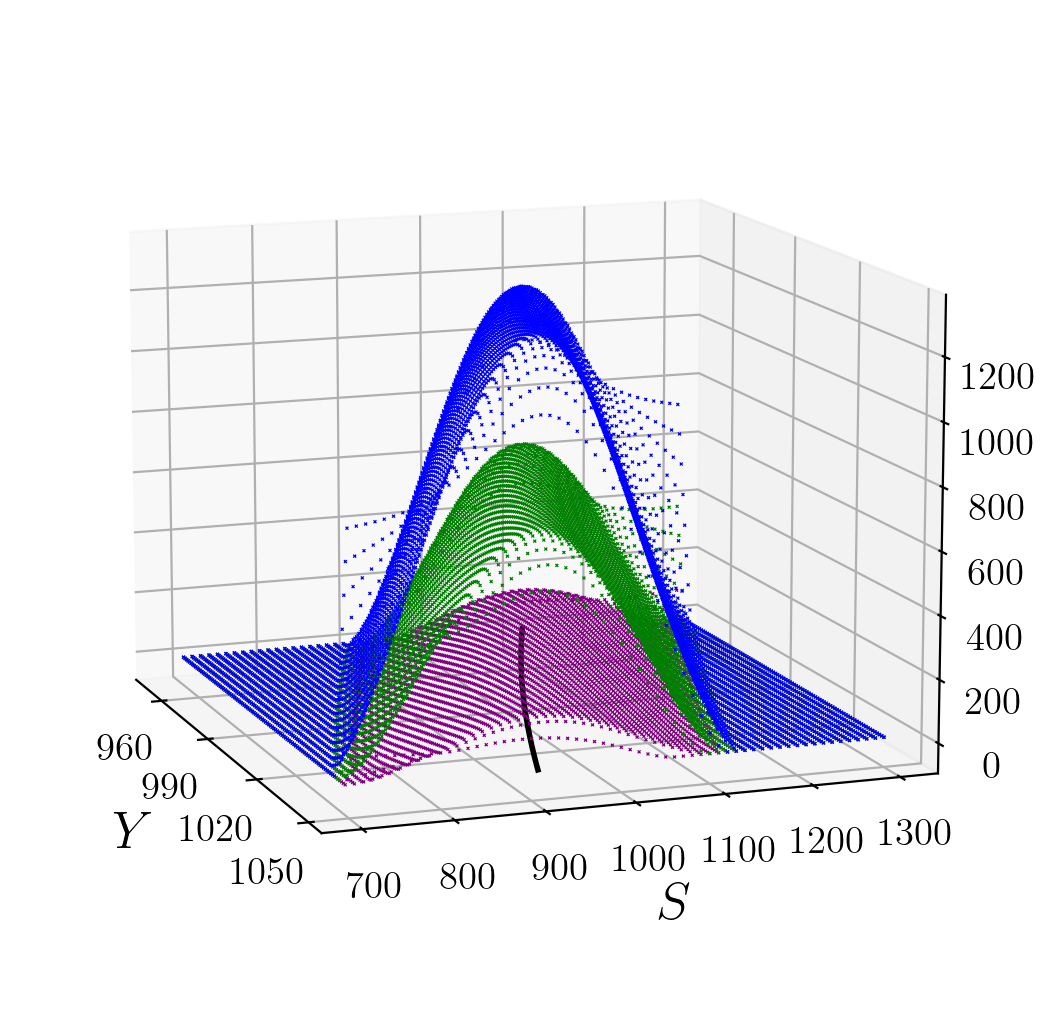

In [ ]:
input_params = {**params_glob, **params_grid, **params_LP}

space, jumps = np.meshgrid(res_euler['external_mid_price_S'], res_euler['jumps_grid'])
value_function_euler = res_euler['V_matrix']

x = jumps.flatten()
y = space.flatten()
#z = value_function_euler[int(params_grid['n_steps']*time_factor), :, :]

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for time_factor_k, color_k, alpha_k in zip([0, 0.5, 0.9], ['blue', 'green', 'purple'], [1, 1, 1]):

    z = value_function_euler[-1 if time_factor == 1 else int(value_function_euler.shape[0]*time_factor_k), :, :]
    scatter = ax.scatter(x, y, z.flatten(), color=color_k, alpha=alpha_k, marker='x', s=0.1, label='Euler')
    #surface = ax.plot_surface(jumps, space, z, color=color_k, alpha=alpha_k, edgecolor='none')

# Local Price Line
x_lp = np.linspace(min(x), max(x), len(x))
y_lp = params_LP['Y0'] * params_LP['X0'] / x_lp**2
z_lp = np.zeros_like(x_lp)
ax.plot(x_lp, y_lp, z_lp, color='black', linewidth=2, label='Local Price')

# LS Line Slices
for k in range(value_function_LS_dict['Y0'].shape[0]):
    ax.plot(np.ones_like(res_euler['external_mid_price_S']) * value_function_LS_dict['Y0'][k], 
            res_euler['external_mid_price_S'], 
            value_function_LS_dict['value_function_LS'][k, :], 
            color='red', marker='.',linewidth=1, label='LS Line Slice')
    
# Add rectangular slices at certain jump levels
slice_jumps = value_function_LS_dict['Y0']
y_min, y_max = np.min(res_euler['external_mid_price_S']), np.max(res_euler['external_mid_price_S'])
z_min, z_max = 0, v_max+100  # Adjust according to your data

for j in slice_jumps:
    verts = [[
        (j, y_min, z_min),
        (j, y_max, z_min),
        (j, y_max, z_max),
        (j, y_min, z_max)
    ]]
    rect = Poly3DCollection(verts, facecolors='black', alpha=0.03, edgecolors='gray', linewidths=1)
    ax.add_collection3d(rect)

# Titre et labels
ax.set_xlabel(r'$Y$', fontsize=fsL,labelpad=8)
ax.set_ylabel(r'$S$', fontsize=fsL,labelpad=8)
ax.set_zlabel(r'$v$', fontsize=fsL,labelpad=8)

# Ajuster la taille des ticks pour les axes X, Y et Z
ax.tick_params(axis='x', labelsize=fs)
ax.tick_params(axis='y', labelsize=fs)
ax.tick_params(axis='z', labelsize=fs)

ax.xaxis.set_major_locator(MaxNLocator(nbins=4))

ax.view_init(elev=12, azim=-20)

fig.subplots_adjust(top=0.99, bottom=0.01)

# Afficher le plot
#plt.savefig(f'3d-plot-euler-vs-ls-{re.sub(r'\.', '-', str(time_factor))}.pdf', dpi=dpi)
plt.savefig(f'3d-plot-euler-time_factor-{re.sub(r'\.', '-', str(time_factor))}.pdf', dpi=dpi)
plt.show()


## 3D Plot to compare Euler surface in risk-neutral and risk-averse case

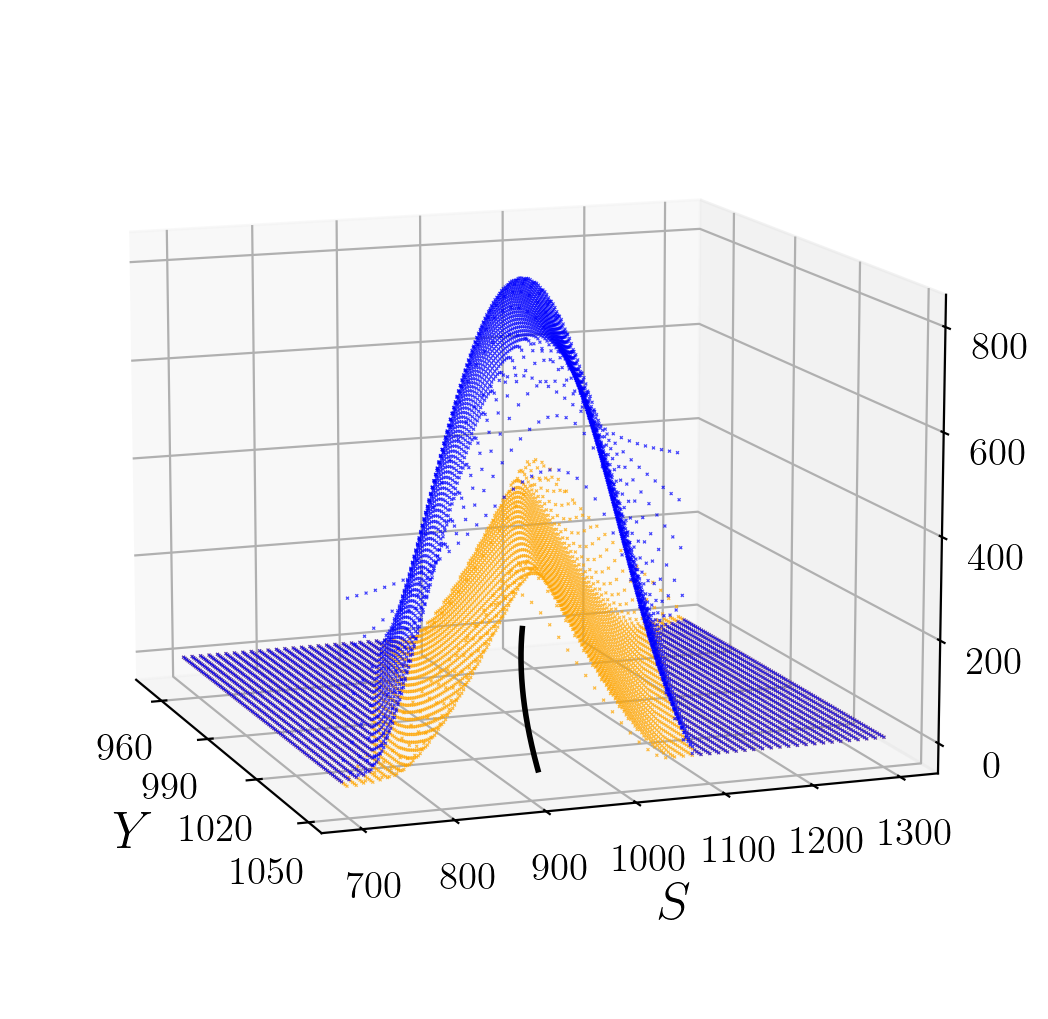

In [ ]:
input_params = {**params_glob, **params_grid, **params_LP}

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

space, jumps = np.meshgrid(all_dicts['res_euler_risk_neutral']['external_mid_price_S'], all_dicts['res_euler_risk_neutral']['jumps_grid'])

x = jumps.flatten()
y = space.flatten()

# Euler risk-neutral
z =  all_dicts['res_euler_risk_neutral']['V_matrix'][0, :, :]
scatter = ax.scatter(x, y, z.flatten(), color='blue', alpha=0.7, marker='x', s=0.1, label='Euler - Risk-Neutral')
#surface = ax.plot_surface(jumps, space, z, color=color_k, alpha=alpha_k, edgecolor='none')

# Euler risk-averse
z = all_dicts['res_euler_risk_averse']['V_matrix'][0, :, :]
scatter = ax.scatter(x, y, z.flatten(), color='orange', alpha=0.7, marker='x', s=0.1, label='Euler - Risk-Averse')
#surface = ax.plot_surface(jumps, space, z, color=color_k, alpha=alpha_k, edgecolor='none')

# Local Price Line
x_lp = np.linspace(min(x), max(x), len(x))
y_lp = params_LP['Y0'] * params_LP['X0'] / x_lp**2
z_lp = np.zeros_like(x_lp)
ax.plot(x_lp, y_lp, z_lp, color='black', linewidth=2, label='Local Price')

# Titre et labels
ax.set_xlabel(r'$Y$', fontsize=fsL,labelpad=8)
ax.set_ylabel(r'$S$', fontsize=fsL,labelpad=8)
ax.set_zlabel(r'$v$', fontsize=fsL,labelpad=8)

# Ajuster la taille des ticks pour les axes X, Y et Z
ax.tick_params(axis='x', labelsize=fs)
ax.tick_params(axis='y', labelsize=fs)
ax.tick_params(axis='z', labelsize=fs)

ax.xaxis.set_major_locator(MaxNLocator(nbins=4))

ax.view_init(elev=12, azim=-20)

fig.subplots_adjust(top=0.99, bottom=0.01)

# Afficher le plot
#plt.savefig(f'3d-plot-euler-vs-ls-{re.sub(r'\.', '-', str(time_factor))}.pdf', dpi=dpi)
plt.savefig(f'3d-plot-euler-risk-avers-neutral-time_factor-{re.sub(r'\.', '-', str(time_factor))}.pdf', dpi=dpi)
plt.show()


# 2D Plots

## 2D Plot to compare Euler and LS methods at time t=0 (with confidence interval) (multiple slices)

In [ ]:
for i in range(value_function_LS_dict['Y0'].shape[0]):
    
    fig, axs = plt.subplots(1, 1, sharex=True, figsize=(8,6))
    #fig.tight_layout()
    
    jump_index = int(np.where(res_euler['jumps_grid'] == value_function_LS_dict['Y0'][i])[0][0])

    plt.scatter(x=res_euler['external_mid_price_S'],y=value_function_euler[0, jump_index, :], label=r'$v_{\mathrm{Euler}}$', color ='tab:blue', marker='x')
    plt.scatter(x=res_euler['external_mid_price_S'],y=value_function_LS_dict['value_function_LS'][i, :], label=r'$v_{\mathrm{LS}}$', color='tab:red', marker='.')
    plt.fill_between(x=res_euler['external_mid_price_S'],y1=value_function_LS_dict['confidence_intervals'][i, :, 0], y2=value_function_LS_dict['confidence_intervals'][i, :, 1], color='tab:red', alpha=0.25)
    plt.xlabel(r'$S$~~$\mathrm{(USDC/ETH)}$', fontsize = fsL+3)
    plt.ylabel(r'$v$', fontsize = fsL+3)
    plt.annotate(r'$Y_0 = ' + str(value_function_LS_dict['Y0'][i]) + '$', xy=(1180, y_max-50), xytext=(1, 0), textcoords='offset points', fontsize=fsL+3)
    plt.legend(fontsize=fsL+4, loc='upper left')

    plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True, prune='lower', nbins=8))
    plt.ylim(-50,y_max + 170)

    fig.subplots_adjust(bottom=0.15)
    plt.savefig(f'2d-plot-euler-vs-ls-{value_function_LS_dict['Y0'][i]}.pdf', dpi=dpi)

    plt.show()